# Looking At edge count distributions on the torus

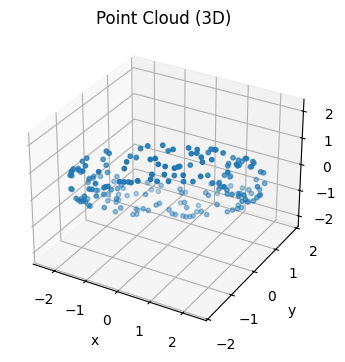

In [1]:
import ecc_vr as vr
import numpy as np
import matplotlib.pyplot as plt

T = vr.sample_point_cloud(shape="torus", n_points=200, ambient_dim=3, seed=42, noise=0.0, Torus_R=2.0, Torus_r=0.5)

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
vr.plot_point_cloud_on_ax(ax, T, 3)
plt.show()


def count_edges(X: np.ndarray, epsilon: float, D: np.ndarray | None = None) -> int:
    X = np.asarray(X, dtype = float)

    if D is None:
        D = vr.pairwise_dist(X)
    
    upper = np.triu(D, k=1)
    edge_count = int(np.sum((upper > 0) & (upper <= epsilon)))
    return edge_count

# Now for the simulation

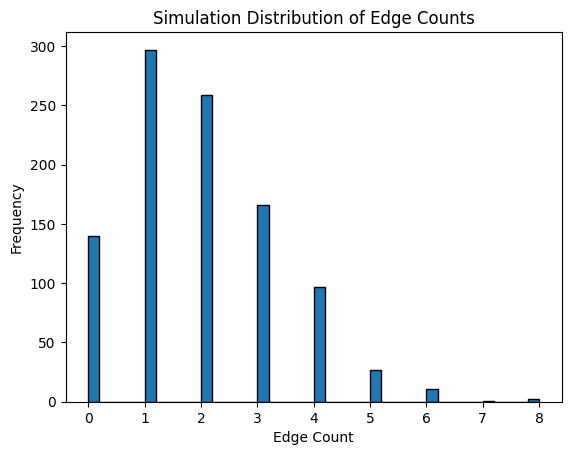

In [2]:

def edge_count_sim_torus(
        n_points: int,
        t: float,
        n_resamples: int,
        R: float = 2.0,
        r: float = 0.5,
        seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)

    edge_counts = np.empty(n_resamples, dtype = int)
    epsilon = t /(n_points ** (1/2))

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0,1_000_000_000))
        X = vr.sample_point_cloud(
            shape="torus", 
            n_points=n_points,
            ambient_dim=3,
            seed=sample_seed, 
            Torus_R=R,
            Torus_r=r)
        edge_counts[i] = count_edges(X, epsilon)

    return edge_counts

edge_counts = edge_count_sim_torus(n_points = 200, t = 0.5, n_resamples = 1000, seed = 234)
plt.hist(edge_counts, bins = 40, edgecolor = "black")
plt.xlabel("Edge Count")
plt.ylabel("Frequency")
plt.title("Simulation Distribution of Edge Counts")
plt.show()

Resamples =    30 | mean = 8.33 | sd = 2.22 | median = 9.00 | 95% interval = [3.73, 12.00]
Resamples =   100 | mean = 7.86 | sd = 2.65 | median = 8.00 | 95% interval = [3.48, 13.00]
Resamples =  1000 | mean = 7.91 | sd = 2.72 | median = 8.00 | 95% interval = [3.00, 14.00]
Resamples = 10000 | mean = 7.92 | sd = 2.82 | median = 8.00 | 95% interval = [3.00, 14.00]


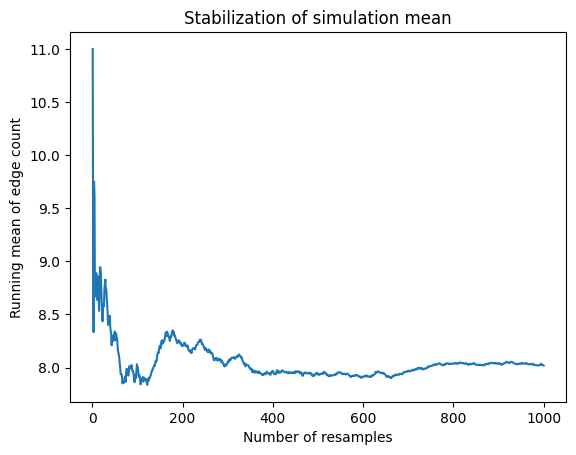

In [5]:
for R in [30,100,1000,10000]:
    edge_counts = edge_count_sim_torus(n_points = 200, t = 1, n_resamples = R, seed = 234)

    mean = edge_counts.mean()
    sd = edge_counts.std(ddof=1)
    q025,q50,q975 = np.quantile(edge_counts, [0.025,0.5,0.975])

    print(
        f"Resamples = {R:5d} | mean = {mean:.2f} | sd = {sd:.2f} | "
        f"median = {q50:.2f} | 95% interval = [{q025:.2f}, {q975:.2f}]"
    )

edge_counts = edge_count_sim_torus(n_points = 200, t = 1, n_resamples = 1000, seed = 134)

k = np.arange(1, len(edge_counts) + 1)
running_mean = np.cumsum(edge_counts) / k

plt.plot(k, running_mean)
plt.xlabel("Number of resamples")
plt.ylabel("Running mean of edge count")
plt.title("Stabilization of simulation mean")
plt.show()




# Notes

For a fixed $t= 0.5$ with $\varepsilon = \frac{t}{n^{(1/d)}}$, when n_points $= 200$, the distribution is centered near $11.5$ edges, with a standard deviation of about $3.4$ and central $95%$ interval of roughly $6$ to $19$ edges. As the number of resamples goes from $30$ to $10,000$, the estimated mean, standard deviation, and quantiles change very little, so the empirical distribution is stabilizing.

In [4]:
from statistics import NormalDist

for n in [50, 100, 250, 500, 1000]:
    counts = edge_count_sim_torus(
        n_points=n,
        t=1,
        n_resamples=100,
        seed=234
    )

    mu = counts.mean()
    sd = counts.std(ddof=1)
    z = (counts - mu) / sd

    skew = np.mean(z**3)
    ex_kurt = np.mean(z**4) - 3

    print(
        f"n = {n:4d} | mean = {mu:.3f} | sd = {sd:.3f} | "
        f"skew = {skew:.3f} | excess kurtosis = {ex_kurt:.3f}"
    )

n =   50 | mean = 2.015 | sd = 1.395 | skew = 0.751 | excess kurtosis = 0.773
n =  100 | mean = 3.855 | sd = 1.894 | skew = 0.494 | excess kurtosis = 0.093
n =  200 | mean = 7.911 | sd = 2.721 | skew = 0.573 | excess kurtosis = 0.939
n =  400 | mean = 16.043 | sd = 4.060 | skew = 0.372 | excess kurtosis = 0.184



KeyboardInterrupt



# Notes

As n_points grows from 50 10 800, the skewness and excess kurtosis move closer to 0, which indicates that the distribution is becoming more normal.

1.95
1.3880805728658825


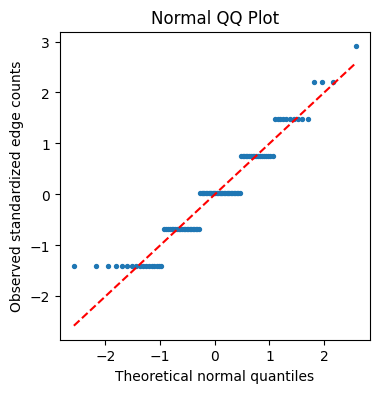

In [ ]:

for t in [1]:
    counts = edge_count_sim_torus(n_points=50, t=t, n_resamples=100, seed=42)

    mu = counts.mean()
    print(mu)
    sd = counts.std(ddof=1)
    print(sd)
    z = np.sort((counts - mu) / sd)

    p = (np.arange(1, len(z) + 1) - 0.5) / len(z)
    q = np.array([NormalDist().inv_cdf(pi) for pi in p])

    fig = plt.figure(figsize=(4, 4))
    plt.scatter(q, z, s=8)
    plt.plot([q.min(), q.max()], [q.min(), q.max()], "r--")
    plt.xlabel("Theoretical normal quantiles")
    plt.ylabel("Observed standardized edge counts")
    plt.title("Normal QQ Plot")
    plt.show()



In [ ]:
#performing some hypothesis tests to verify normality

from scipy.stats import shapiro

#for n_points in [50,100,500,1000]:
 #   for t in [1]:
  #      counts = edge_count_sim_torus(n_points=n_points, t=t, n_resamples=100, seed=234)

        #SW test
   #     stat_s, p_s = shapiro(counts)
    #    print(f"Shapiro-Wilk p-value for {n_points} points and t = {t}:", p_s)


def edge_count_sim_sphere(
        n_points: int,
        t: float,
        n_resamples: int,
        R: float = 2.0,
        r: float = 0.5,
        seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)

    edge_counts = np.empty(n_resamples, dtype = int)
    epsilon = t /(n_points ** (1/2))

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0,1_000_000_000))
        X = vr.sample_point_cloud(
            shape="sphere", 
            n_points=n_points,
            ambient_dim=3,
            seed=sample_seed 
            )
        edge_counts[i] = count_edges(X, epsilon)

    return edge_counts

for n_points in [50,100,250,500,1000]:
    for t in [1]:
        counts = edge_count_sim_sphere(n_points=n_points, t=t, n_resamples=100,seed=42)

        #SW test
        stat_s, p_s = shapiro(counts)
        print(f"Shapiro-Wilk p-value for {n_points} points and t = {t}:", p_s)



Shapiro-Wilk p-value for 50 points and t = 1: 0.0008892994571619176
Shapiro-Wilk p-value for 100 points and t = 1: 0.08278382448223026
Shapiro-Wilk p-value for 250 points and t = 1: 0.15038624552301752
Shapiro-Wilk p-value for 500 points and t = 1: 0.015731199614452504
Shapiro-Wilk p-value for 1000 points and t = 1: 0.7647388509186378


In [ ]:
for n_points in [50,100,1000,10000]:
    edge_counts = edge_count_sim_sphere(n_points = n_points, t = 1, n_resamples = 100, seed = 42)

    mean = edge_counts.mean()
    sd = edge_counts.std(ddof=1)
    q025,q50,q975 = np.quantile(edge_counts, [0.025,0.5,0.975])

    print(
        f"Points = {n_points:5d} | mean = {mean:.2f} | sd = {sd:.2f} | "
        f"median = {q50:.2f} | 95% interval = [{q025:.2f}, {q975:.2f}]"
    )


Points =    50 | mean = 6.01 | sd = 2.47 | median = 5.00 | 95% interval = [2.00, 11.00]
Points =   100 | mean = 12.06 | sd = 3.37 | median = 12.00 | 95% interval = [6.47, 18.52]
Points =  1000 | mean = 127.88 | sd = 11.00 | median = 128.00 | 95% interval = [106.47, 146.52]


# Notes and Conclusions

The QQ plot for this case is fairly close to a straight line, with only some mild tail deviations. Therefore, the edge-count distribution appears approximately normal for sufficiently large point samples, though not perfectly normal in small or moderate samples. 

The normal testing however unveiled some more complex behavior. At the $5%$ level, the SW results say to reject normality for all scenarios except for n_points = 800 with t = 0.5. This shows that the edge-count distribution is not exactly normal (obvious since its only integer valued). This also tells us that the evidence for normality is limited and not monotone in n_points. 


